# NumCompute – Streaming ML Demo

This notebook demonstrates the full streaming pipeline:
1. Load a CSV dataset using `io.py`
2. Split into chunks to simulate a data stream
3. Train models incrementally with `.partial_fit()`
4. Log and visualise metrics per chunk using `visualise.py`

In [26]:
import numpy as np
import sys
sys.path.insert(0, '..')

from numcompute.preprocessing import StandardScaler, SimpleImputer
from numcompute.pipeline import Pipeline
from numcompute.tree import DecisionTreeClassifier, RandomForestClassifier
from numcompute.ensemble import EnsembleClassifier
from numcompute.stream import StreamTrainer
from numcompute.metrics import StreamingMetrics, roc_curve, auc
from numcompute.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
    plot_confusion_matrix,
    plot_cumulative_accuracy,
    plot_memory_over_time,
    plot_roc_curve,
)

print('Imports OK')

Imports OK


## 1. Load Dataset

We use a synthetic CSV here. Replace `data_path` with your real CSV file.
The last column is treated as the label.

In [27]:
# --- Generate a synthetic CSV if you don't have a real one ----------
import os

data_path = r'C:\Users\aarib\OneDrive\Documents\AdelUni\Semester 1\ProgrammingAI\programming_task_1\data\WineQT.csv'

data = np.genfromtxt(data_path, delimiter=',', skip_header=1)
X_all = data[:, :-1]   # all columns except last
y_all = data[:, -1].astype(int)   # last column = label

print(f'Loaded: X={X_all.shape}, y={y_all.shape}')
print(f'Classes: {np.unique(y_all)}')
print(f'NaNs in X: {np.isnan(X_all).sum()}')

Loaded: X=(1143, 12), y=(1143,)
Classes: [   0    1    2 ... 1594 1595 1597]
NaNs in X: 0


## 2. Split into Chunks (simulate streaming)

In [28]:
CHUNK_SIZE = 60
n = len(y_all)

chunks = [
    (X_all[i:i+CHUNK_SIZE], y_all[i:i+CHUNK_SIZE])
    for i in range(0, n, CHUNK_SIZE)
]

# Hold out the last chunk as validation
train_chunks = chunks[:-1]
X_val, y_val = chunks[-1]

print(f'{len(train_chunks)} training chunks of size {CHUNK_SIZE}')
print(f'Validation chunk: {len(y_val)} samples')

19 training chunks of size 60
Validation chunk: 3 samples


## 3. Build Pipelines

Each pipeline: `SimpleImputer → StandardScaler → Model`

In [29]:
def make_pipeline(model):
    return Pipeline([
        ('impute', SimpleImputer()),
        ('scale',  StandardScaler()),
        ('model',  model),
    ])

pipe_tree   = make_pipeline(DecisionTreeClassifier(max_depth=4))
pipe_forest = make_pipeline(RandomForestClassifier(n_estimators=10, max_depth=4))
pipe_bag    = make_pipeline(EnsembleClassifier(method='bagging',  n_estimators=10, max_depth=4))
pipe_boost  = make_pipeline(EnsembleClassifier(method='boosting', n_estimators=10, max_depth=1))

trainer_tree   = StreamTrainer(pipe_tree,   verbose=False)
trainer_forest = StreamTrainer(pipe_forest, verbose=False)
trainer_bag    = StreamTrainer(pipe_bag,    verbose=False)
trainer_boost  = StreamTrainer(pipe_boost,  verbose=False)

print('Pipelines ready')

Pipelines ready


## 4. Incremental Training

In [30]:
sm_tree   = StreamingMetrics(window=3)
sm_forest = StreamingMetrics(window=3)

for X_chunk, y_chunk in train_chunks:
    # Fit each model on this chunk
    trainer_tree.fit_chunk(X_chunk, y_chunk)
    trainer_forest.fit_chunk(X_chunk, y_chunk)
    trainer_bag.fit_chunk(X_chunk, y_chunk)
    trainer_boost.fit_chunk(X_chunk, y_chunk)

    # Update streaming metrics
    sm_tree.update(y_chunk,   pipe_tree.predict(X_chunk))
    sm_forest.update(y_chunk, pipe_forest.predict(X_chunk))

print('Training complete')
print(f'Tree   cumulative accuracy: {trainer_tree.cumulative_accuracy():.4f}')
print(f'Forest cumulative accuracy: {trainer_forest.cumulative_accuracy():.4f}')

Training complete
Tree   cumulative accuracy: 0.0263
Forest cumulative accuracy: 0.0395


## 5. Streaming Metrics Summary

In [31]:
print('=== Decision Tree ===')
print(sm_tree.result())

print('\n=== Random Forest ===')
print(sm_forest.result())

# Rolling window (last 3 chunks)
print('\n=== Forest Rolling (last 3 chunks) ===')
print(sm_forest.result_rolling())

=== Decision Tree ===
{'n_samples': 1140, 'accuracy': np.float64(0.02631578947368421), 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'confusion_matrix': array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]], shape=(1140, 1140))}

=== Random Forest ===
{'n_samples': 1140, 'accuracy': np.float64(0.039473684210526314), 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'confusion_matrix': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1140, 1140))}

=== Forest Rolling (last 3 chunks) ===
{'window': 3, 'n_samples': 180, 'accuracy': 0.0, 'precision': nan, 'recall': nan, 'f1': nan, 'confusion_matrix': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0,

## 6. Visualisations

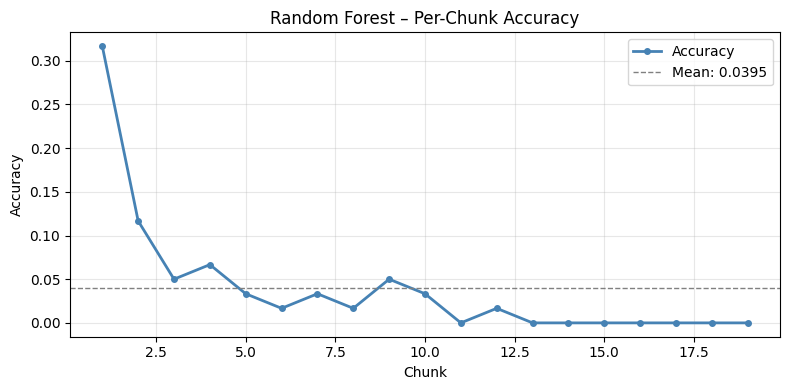

In [32]:
# --- Required plot 1: metric over time --------------------------------
plot_metric_over_time(
    trainer_forest.accuracy_history(),
    title='Random Forest – Per-Chunk Accuracy',
    ylabel='Accuracy'
)

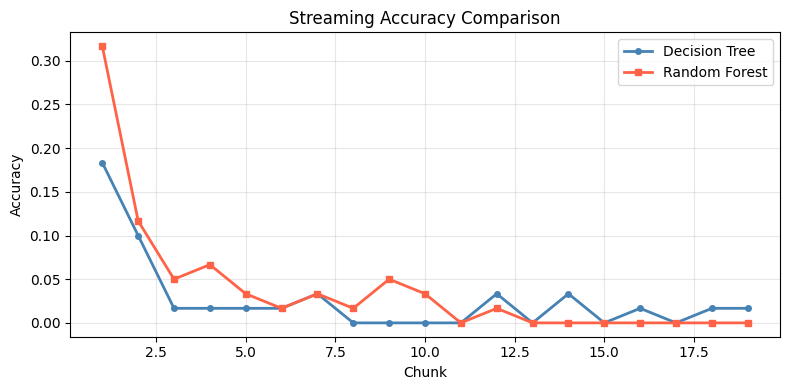

In [33]:
# --- Required plot 2: compare models ----------------------------------
compare_models(
    trainer_tree.accuracy_history(),
    trainer_forest.accuracy_history(),
    labels=('Decision Tree', 'Random Forest'),
    title='Streaming Accuracy Comparison',
    ylabel='Accuracy'
)

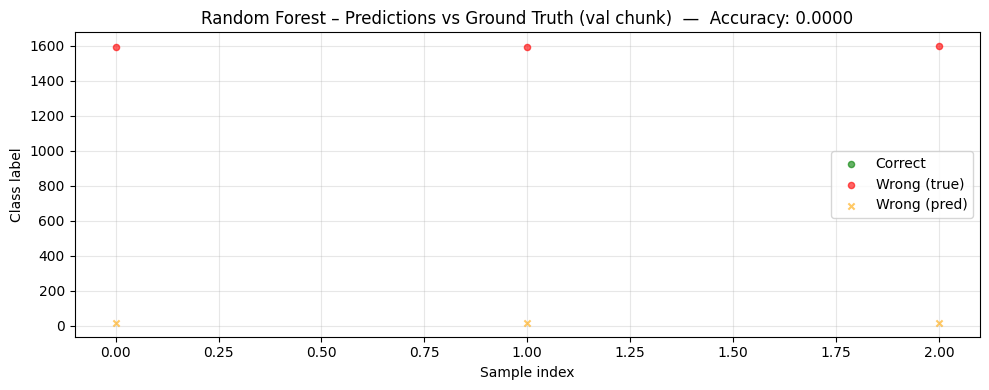

In [34]:
# --- Required plot 3: predictions vs ground truth (last chunk) --------
y_pred_last = pipe_forest.predict(X_val)
plot_predictions_vs_ground_truth(
    y_val, y_pred_last,
    title='Random Forest – Predictions vs Ground Truth (val chunk)'
)

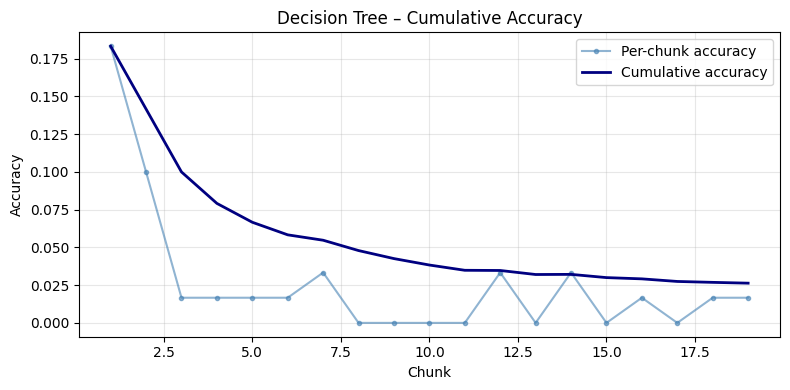

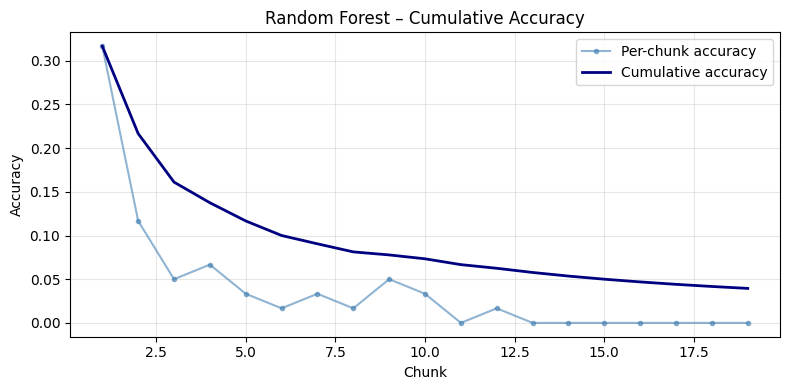

In [35]:
# --- Extra: cumulative accuracy both models ---------------------------
plot_cumulative_accuracy(trainer_tree.log,   title='Decision Tree – Cumulative Accuracy')
plot_cumulative_accuracy(trainer_forest.log, title='Random Forest – Cumulative Accuracy')

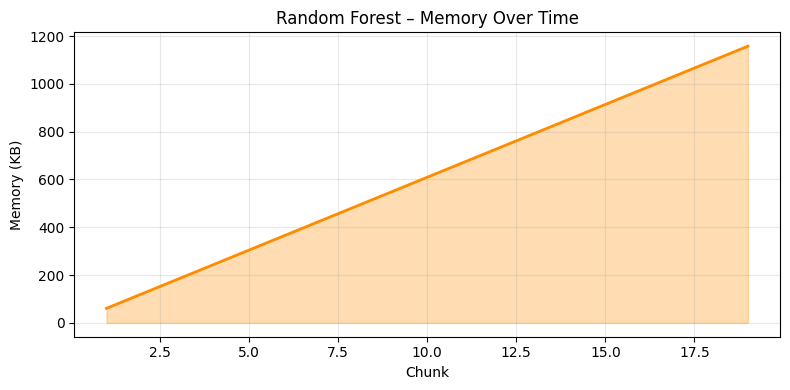

In [36]:
# --- Extra: memory footprint ------------------------------------------
plot_memory_over_time(trainer_forest.log, title='Random Forest – Memory Over Time')

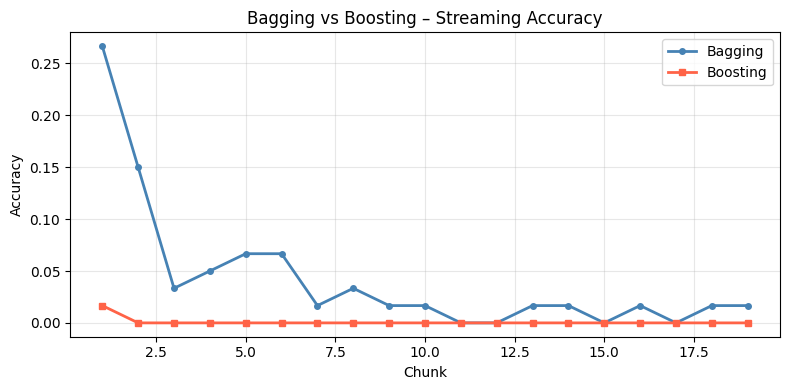

In [37]:
# --- Extra: bagging vs boosting accuracy ------------------------------
compare_models(
    trainer_bag.accuracy_history(),
    trainer_boost.accuracy_history(),
    labels=('Bagging', 'Boosting'),
    title='Bagging vs Boosting – Streaming Accuracy',
    ylabel='Accuracy'
)

## 7. Trainer Summaries

In [39]:
trainer_tree.summary()



 Chunk       N       Acc   Cum Acc   Time(s)   Mem(KB)
-----------------------------------------------------------------
     1      60    0.1833    0.1833    0.0391       6.1
     2      60    0.1000    0.1417    0.0783      12.2
     3      60    0.0167    0.1000    0.1107      18.3
     4      60    0.0167    0.0792    0.1853      24.4
     5      60    0.0167    0.0667    0.2188      30.5
     6      60    0.0167    0.0583    0.2467      36.6
     7      60    0.0333    0.0548    0.2878      42.7
     8      60    0.0000    0.0479    0.3458      48.8
     9      60    0.0000    0.0426    0.4014      54.8
    10      60    0.0000    0.0383    0.4611      60.9
    11      60    0.0000    0.0348    0.5365      67.0
    12      60    0.0333    0.0347    0.5888      73.1
    13      60    0.0000    0.0321    0.6550      79.2
    14      60    0.0333    0.0321    0.7160      85.3
    15      60    0.0000    0.0300    0.8495      91.4
    16      60    0.0167    0.0292    0.8356      97.

In [40]:
trainer_forest.summary()



 Chunk       N       Acc   Cum Acc   Time(s)   Mem(KB)
-----------------------------------------------------------------
     1      60    0.3167    0.3167    0.0658      60.9
     2      60    0.1167    0.2167    0.1390     121.9
     3      60    0.0500    0.1611    0.2151     182.8
     4      60    0.0667    0.1375    0.3127     243.8
     5      60    0.0333    0.1167    0.4163     304.7
     6      60    0.0167    0.1000    0.5163     365.6
     7      60    0.0333    0.0905    0.5610     426.6
     8      60    0.0167    0.0813    0.6844     487.5
     9      60    0.0500    0.0778    0.8128     548.4
    10      60    0.0333    0.0733    0.9048     609.4
    11      60    0.0000    0.0667    1.1766     670.3
    12      60    0.0167    0.0625    1.1536     731.2
    13      60    0.0000    0.0577    1.2599     792.2
    14      60    0.0000    0.0536    1.4236     853.1
    15      60    0.0000    0.0500    1.7085     914.1
    16      60    0.0000    0.0469    1.8226     975.

In [41]:
trainer_bag.summary()



 Chunk       N       Acc   Cum Acc   Time(s)   Mem(KB)
-----------------------------------------------------------------
     1      60    0.2667    0.2667    0.0660       0.0
     2      60    0.1500    0.2083    0.1433       0.0
     3      60    0.0333    0.1500    0.2260       0.0
     4      60    0.0500    0.1250    0.3388       0.0
     5      60    0.0667    0.1133    0.4164       0.0
     6      60    0.0667    0.1056    0.4958       0.0
     7      60    0.0167    0.0929    0.5952       0.0
     8      60    0.0333    0.0854    0.7018       0.0
     9      60    0.0167    0.0778    0.7895       0.0
    10      60    0.0167    0.0717    0.9154       0.0
    11      60    0.0000    0.0652    1.0974       0.0
    12      60    0.0000    0.0597    1.2115       0.0
    13      60    0.0167    0.0564    1.2679       0.0
    14      60    0.0167    0.0536    1.5400       0.0
    15      60    0.0000    0.0500    1.5953       0.0
    16      60    0.0167    0.0479    2.1396       0.

In [42]:
trainer_boost.summary()


 Chunk       N       Acc   Cum Acc   Time(s)   Mem(KB)
-----------------------------------------------------------------
     1      60    0.0167    0.0167    0.0070       0.0
     2      60    0.0000    0.0083    0.0084       0.0
     3      60    0.0000    0.0056    0.0070       0.0
     4      60    0.0000    0.0042    0.0084       0.0
     5      60    0.0000    0.0033    0.0080       0.0
     6      60    0.0000    0.0028    0.0076       0.0
     7      60    0.0000    0.0024    0.0068       0.0
     8      60    0.0000    0.0021    0.0076       0.0
     9      60    0.0000    0.0019    0.0077       0.0
    10      60    0.0000    0.0017    0.0062       0.0
    11      60    0.0000    0.0015    0.0087       0.0
    12      60    0.0000    0.0014    0.0073       0.0
    13      60    0.0000    0.0013    0.0070       0.0
    14      60    0.0000    0.0012    0.0072       0.0
    15      60    0.0000    0.0011    0.0072       0.0
    16      60    0.0000    0.0010    0.0073       0.